# Fake News Detection using Machine Learning

---
### Notebook structure
| Phase | Content |
|-------|---------|
| 1 | Environment setup & library imports |
| 2 | Data loading & exploratory analysis |
| 3 | Text preprocessing pipeline |
| 4 | Feature engineering (TF-IDF & BoW) |
| 5 | Classifier training & hyperparameter tuning |
| 6 | Results visualisation & analysis |
| 7 | Feature interpretability analysis |

---
## Phase 1 — Environment Setup & Library Imports

In [1]:
# Install required libraries (run once; comment out after first run)
# !pip install scikit-learn nltk pandas numpy matplotlib seaborn wordcloud tqdm

In [2]:
import warnings
warnings.filterwarnings('ignore')

# ── Standard library ──────────────────────────────────────────────────────
import re
import time
import string

# ── Data & numerical ──────────────────────────────────────────────────────
import numpy as np
import pandas as pd

# ── Visualisation ─────────────────────────────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from wordcloud import WordCloud

# ── NLTK ──────────────────────────────────────────────────────────────────
import nltk
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer, PorterStemmer

# ── Scikit-learn: feature extraction ──────────────────────────────────────
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer

# ── Scikit-learn: classifiers ─────────────────────────────────────────────
from sklearn.linear_model import LogisticRegression, PassiveAggressiveClassifier
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import MultinomialNB

# ── Scikit-learn: model selection & evaluation ────────────────────────────
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, classification_report, confusion_matrix
)

# ── Progress bar ──────────────────────────────────────────────────────────
from tqdm.auto import tqdm
tqdm.pandas()

print('All libraries imported successfully.')

All libraries imported successfully.


In [3]:
# Download all NLTK corpora needed by the preprocessing pipeline
for corpus in ['stopwords', 'wordnet', 'omw-1.4', 'punkt', 'punkt_tab', 'averaged_perceptron_tagger']:
    nltk.download(corpus, quiet=True)

# Global plot style
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.05)
plt.rcParams.update({'figure.dpi': 120, 'figure.figsize': (10, 5)})

RANDOM_STATE = 42
print('NLTK corpora downloaded. Plot theme configured.')

NLTK corpora downloaded. Plot theme configured.


---
## Phase 2 — Data Loading & Exploratory Analysis

The **ISOT Fake News Dataset** is sourced from the University of Victoria. Real articles come from Reuters; fake articles come from outlets flagged by PolitiFact and Wikipedia as unreliable.

> **Download:** [Kaggle – ISOT Fake News Dataset](https://www.kaggle.com/datasets/emineyetm/fake-news-detection-datasets)  
> Place `Fake.csv` and `True.csv` in the same directory as this notebook, or update the paths below.

In [4]:
# ── Load raw CSVs ────────────────────────────────────────────────────────
fake_df = pd.read_csv('Fake.csv')
true_df = pd.read_csv('True.csv')

# Add binary label: 1 = fake, 0 = real
fake_df['label'] = 1
true_df['label'] = 0

# Combine and shuffle with fixed seed for reproducibility
df = pd.concat([fake_df, true_df], ignore_index=True)
df = df.sample(frac=1, random_state=RANDOM_STATE).reset_index(drop=True)

print(f'Total articles : {len(df):,}')
print(f'Columns        : {list(df.columns)}')
print(f'\nClass distribution:')
print(df['label'].value_counts().rename({0: 'Real', 1: 'Fake'}).to_string())
df.head(3)

Total articles : 44,898
Columns        : ['title', 'text', 'subject', 'date', 'label']

Class distribution:
label
Fake    23481
Real    21417


,title,text,subject,date,label
0,Ben Stein Calls Out 9th Circuit Court: Committ...,"21st Century Wire says Ben Stein, reputable pr...",US_News,"February 13, 2017",1
1,Trump drops Steve Bannon from National Securit...,WASHINGTON (Reuters) - U.S. President Donald T...,politicsNews,"April 5, 2017",0
2,Puerto Rico expects U.S. to lift Jones Act shi...,(Reuters) - Puerto Rico Governor Ricardo Rosse...,politicsNews,"September 27, 2017",0


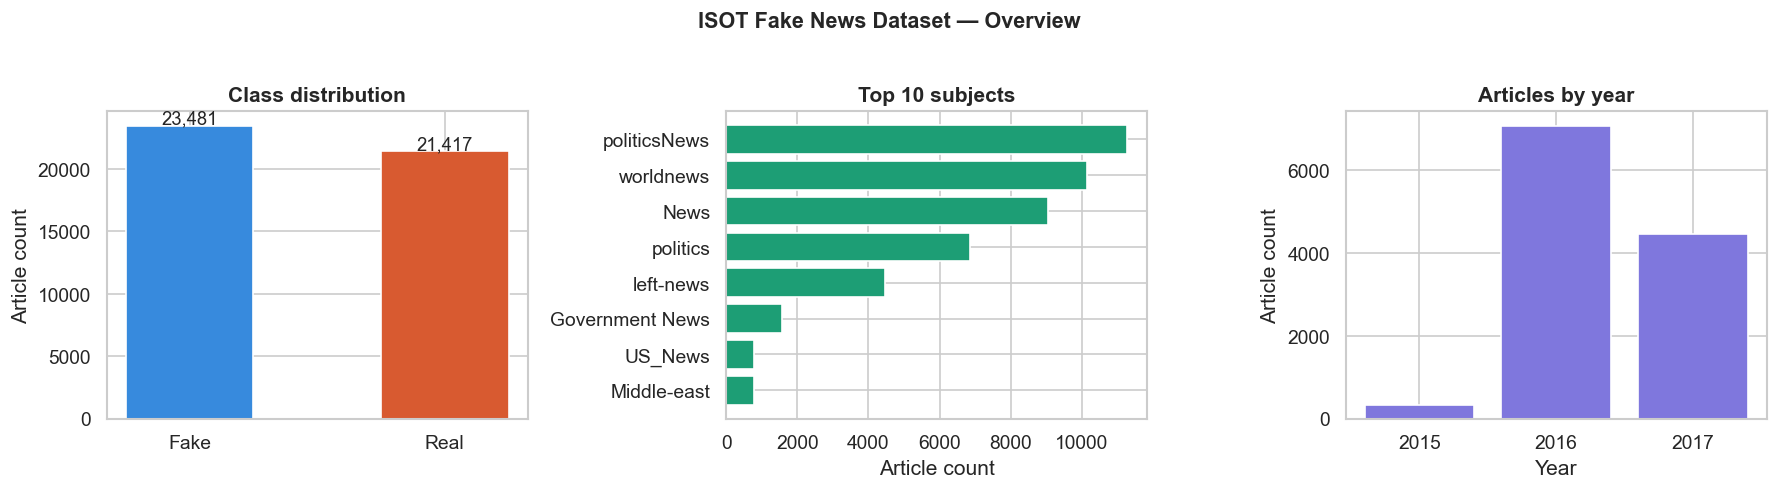

In [5]:
# ── Class balance bar chart ───────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# 1. Class counts
counts = df['label'].value_counts().rename({0: 'Real', 1: 'Fake'})
axes[0].bar(counts.index, counts.values, color=['#378ADD', '#D85A30'], width=0.5)
axes[0].set_title('Class distribution', fontweight='bold')
axes[0].set_ylabel('Article count')
for bar, val in zip(axes[0].patches, counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 150,
                 f'{val:,}', ha='center', fontsize=11)

# 2. Subject distribution
if 'subject' in df.columns:
    subj = df['subject'].value_counts().head(10)
    axes[1].barh(subj.index[::-1], subj.values[::-1], color='#1D9E75')
    axes[1].set_title('Top 10 subjects', fontweight='bold')
    axes[1].set_xlabel('Article count')
else:
    axes[1].text(0.5, 0.5, 'No subject column', ha='center', va='center')
    axes[1].set_title('Subject distribution')

# 3. Year distribution
if 'date' in df.columns:
    df['year'] = pd.to_datetime(df['date'], errors='coerce').dt.year
    year_counts = df.dropna(subset=['year'])['year'].astype(int).value_counts().sort_index()
    axes[2].bar(year_counts.index.astype(str), year_counts.values, color='#7F77DD')
    axes[2].set_title('Articles by year', fontweight='bold')
    axes[2].set_xlabel('Year')
    axes[2].set_ylabel('Article count')
else:
    axes[2].text(0.5, 0.5, 'No date column', ha='center', va='center')
    axes[2].set_title('Publication year')

plt.suptitle('ISOT Fake News Dataset — Overview', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('fig_dataset_overview.png', bbox_inches='tight')
plt.show()

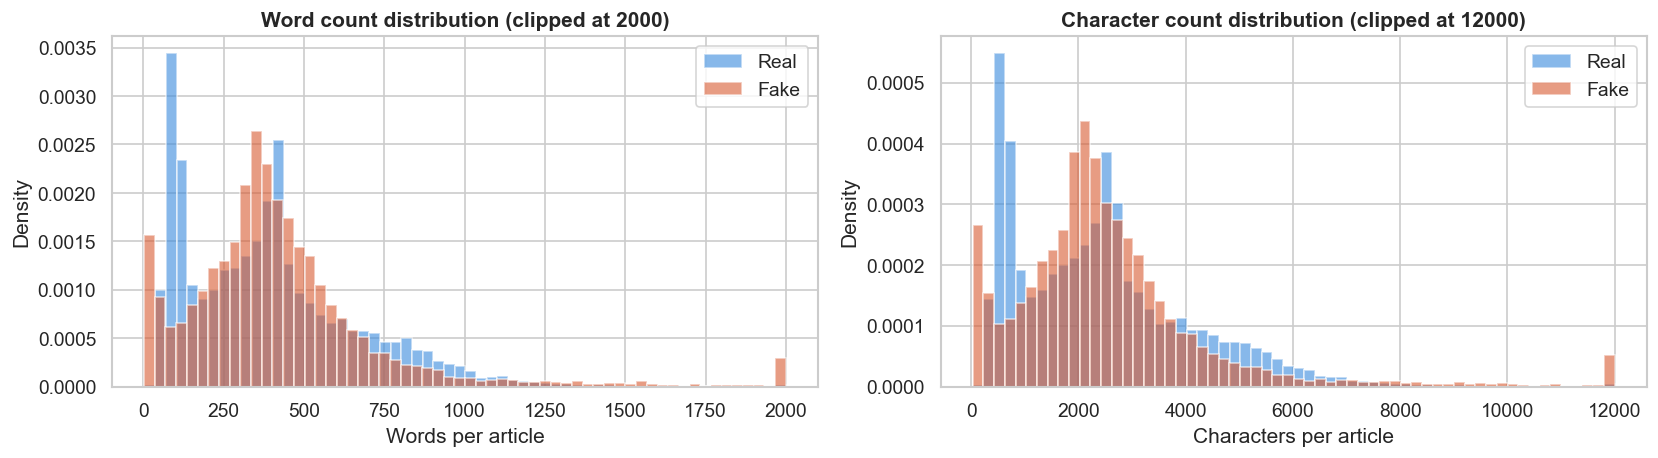

Summary statistics — word count:
         count   mean    std  min    25%    50%    75%     max
label                                                         
Real   21417.0  395.6  273.9  4.0  159.0  369.0  534.0  5181.0
Fake   23481.0  437.9  408.6  2.0  254.0  378.0  521.0  8148.0


In [6]:
# ── Article length analysis ───────────────────────────────────────────────
# Combine title + text for length measurement (mirrors preprocessing step)
df['combined_text'] = df['title'].fillna('') + ' ' + df['text'].fillna('')
df['char_count'] = df['combined_text'].str.len()
df['word_count'] = df['combined_text'].str.split().str.len()

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
colors = {0: '#378ADD', 1: '#D85A30'}
labels = {0: 'Real', 1: 'Fake'}

for lbl in [0, 1]:
    subset = df[df['label'] == lbl]
    axes[0].hist(subset['word_count'].clip(upper=2000), bins=60,
                 alpha=0.6, color=colors[lbl], label=labels[lbl], density=True)
    axes[1].hist(subset['char_count'].clip(upper=12000), bins=60,
                 alpha=0.6, color=colors[lbl], label=labels[lbl], density=True)

for ax, title, xlab in zip(axes,
    ['Word count distribution (clipped at 2000)', 'Character count distribution (clipped at 12000)'],
    ['Words per article', 'Characters per article']):
    ax.set_title(title, fontweight='bold')
    ax.set_xlabel(xlab)
    ax.set_ylabel('Density')
    ax.legend()

plt.tight_layout()
plt.savefig('fig_length_distribution.png', bbox_inches='tight')
plt.show()

print('Summary statistics — word count:')
print(df.groupby('label')['word_count'].describe().rename({0: 'Real', 1: 'Fake'}).round(1))

---
## Phase 3 — Text Preprocessing Pipeline

The pipeline implements four stages:

1. **Lowercase + noise removal** — URLs, HTML, punctuation, standalone numerals
2. **Tokenization** — NLTK `word_tokenize`
3. **Stopword removal** — NLTK English list, *retaining* `we`, `our`, `us` (credibility-assessment literature rationale)
4. **WordNet lemmatization** — preferred over stemming to avoid false conflations (e.g. `universe` / `university`)

In [7]:
# ── Build stopword set with deliberate pronoun exceptions ────────────────
KEEP_PRONOUNS = {'we', 'our', 'us'}  # retained per Section 3.2
STOP_WORDS = set(stopwords.words('english')) - KEEP_PRONOUNS

lemmatizer = WordNetLemmatizer()

def preprocess(text: str) -> str:
    """Full 4-stage preprocessing pipeline (Section 3.2)."""
    # Stage 1 — lowercase and noise removal
    text = text.lower()
    text = re.sub(r'https?://\S+|www\.\S+', ' ', text)   # URLs
    text = re.sub(r'<.*?>', ' ', text)                     # HTML tags
    text = re.sub(r'[^\w\s]', ' ', text)                  # punctuation
    text = re.sub(r'\b\d+\b', ' ', text)                  # standalone numerals
    text = re.sub(r'\s+', ' ', text).strip()              # collapse whitespace

    # Stage 2 — tokenize
    tokens = word_tokenize(text)

    # Stage 3 — stopword removal (keep first-person plurals)
    tokens = [t for t in tokens if t not in STOP_WORDS and len(t) > 1]

    # Stage 4 — WordNet lemmatization
    tokens = [lemmatizer.lemmatize(t) for t in tokens]

    return ' '.join(tokens)


print('Preprocessing function defined.')
print(f'Stopword list size: {len(STOP_WORDS)} (NLTK default minus {KEEP_PRONOUNS})')

Preprocessing function defined.
Stopword list size: 196 (NLTK default minus {'we', 'our', 'us'})


In [8]:
# ── Stemmer vs Lemmatizer comparison (justification cell) ────────────────
stemmer = PorterStemmer()
demo_tokens = ['universe', 'university', 'running', 'better', 'government',
               'policies', 'breaking', 'announced', 'shocking', 'reported']

comparison = pd.DataFrame({
    'Original': demo_tokens,
    'Porter stemmer': [stemmer.stem(t) for t in demo_tokens],
    'WordNet lemmatizer': [lemmatizer.lemmatize(t) for t in demo_tokens]
})

print('Stemmer vs Lemmatizer — example tokens:')
print(comparison.to_string(index=False))
print('\nNote: stemmer conflates "universe" and "university" (same stem "univers").')
print('Lemmatizer preserves the distinction. This is why the paper uses lemmatization.')

Stemmer vs Lemmatizer — example tokens:
  Original Porter stemmer WordNet lemmatizer
  universe        univers           universe
university        univers         university
   running            run            running
    better         better             better
government         govern         government
  policies         polici             policy
  breaking          break           breaking
 announced        announc          announced
  shocking          shock           shocking
  reported         report           reported

Note: stemmer conflates "universe" and "university" (same stem "univers").
Lemmatizer preserves the distinction. This is why the paper uses lemmatization.


In [9]:
# ── Apply pipeline to the full corpus (this takes 2-5 minutes) ───────────
print('Merging title + body text...')
df['combined_text'] = df['title'].fillna('') + ' ' + df['text'].fillna('')

print('Running preprocessing pipeline (progress bar below)...')
df['clean_text'] = df['combined_text'].progress_apply(preprocess)

# Sanity check on one article
idx = 0
print('\n─── Sample article ─────────────────────────────────────────────────────')
print('ORIGINAL (first 300 chars):', df['combined_text'].iloc[idx][:300])
print('\nCLEAN (first 300 chars)   :', df['clean_text'].iloc[idx][:300])

Merging title + body text...
Running preprocessing pipeline (progress bar below)...


100%|███████████████████████████████████████████████████████████████████████████| 44898/44898 [01:29<00:00, 503.08it/s]


─── Sample article ─────────────────────────────────────────────────────
ORIGINAL (first 300 chars): Ben Stein Calls Out 9th Circuit Court: Committed a ‘Coup d’état’ Against the Constitution 21st Century Wire says Ben Stein, reputable professor from, Pepperdine University (also of some Hollywood fame appearing in TV shows and films such as Ferris Bueller s Day Off) made some provocative statements 

CLEAN (first 300 chars)   : ben stein call 9th circuit court committed coup état constitution 21st century wire say ben stein reputable professor pepperdine university also hollywood fame appearing tv show film ferris bueller day made provocative statement judge jeanine pirro show recently discussing halt imposed president tru


---
## Phase 4 — Feature Engineering: TF-IDF & BoW Schemes

Four vectorization schemes are evaluated. For all TF-IDF variants, `max_features=50,000` selected by descending average TF-IDF score within the training partition.

| Scheme | Vectorizer | `ngram_range` |
|--------|-----------|---------------|
| BoW unigrams | `CountVectorizer` | (1,1) |
| TF-IDF unigrams | `TfidfVectorizer` | (1,1) |
| TF-IDF bigrams | `TfidfVectorizer` | (2,2) |
| TF-IDF unigrams+bigrams | `TfidfVectorizer` | (1,2) |

> **Data leakage prevention:** vectorizers are `fit` only on `X_train`, then `transform` is applied to both splits separately.

In [10]:
# ── Stratified 80/20 train-test split ─────────────────────────────────────
X = df['clean_text'].values
y = df['label'].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=RANDOM_STATE, stratify=y
)

print(f'Training set : {len(X_train):,} articles  '
      f'({y_train.sum():,} fake / {(y_train==0).sum():,} real)')
print(f'Test set     : {len(X_test):,} articles  '
      f'({y_test.sum():,} fake / {(y_test==0).sum():,} real)')
print(f'\nClass ratio in train: {y_train.mean():.3f}  |  test: {y_test.mean():.3f}')

Training set : 35,918 articles  (18,785 fake / 17,133 real)
Test set     : 8,980 articles  (4,696 fake / 4,284 real)

Class ratio in train: 0.523  |  test: 0.523


In [11]:
# ── Instantiate all four vectorization schemes ───────────────────────────
MAX_FEATURES = 50_000

vectorizers = {
    'BoW — Unigrams':          CountVectorizer(max_features=MAX_FEATURES, ngram_range=(1, 1)),
    'TF-IDF — Unigrams':       TfidfVectorizer(max_features=MAX_FEATURES, ngram_range=(1, 1), sublinear_tf=True),
    'TF-IDF — Bigrams':        TfidfVectorizer(max_features=MAX_FEATURES, ngram_range=(2, 2), sublinear_tf=True),
    'TF-IDF — Uni+Bigrams':    TfidfVectorizer(max_features=MAX_FEATURES, ngram_range=(1, 2), sublinear_tf=True),
}

# Fit on train, transform both splits — store in dict keyed by scheme name
X_train_vecs = {}
X_test_vecs  = {}

for name, vec in vectorizers.items():
    X_train_vecs[name] = vec.fit_transform(X_train)   # fit on train only
    X_test_vecs[name]  = vec.transform(X_test)         # apply to test
    print(f'{name:<30}  train shape: {X_train_vecs[name].shape}  |  '
          f'test shape: {X_test_vecs[name].shape}')

BoW — Unigrams                  train shape: (35918, 50000)  |  test shape: (8980, 50000)
TF-IDF — Unigrams               train shape: (35918, 50000)  |  test shape: (8980, 50000)
TF-IDF — Bigrams                train shape: (35918, 50000)  |  test shape: (8980, 50000)
TF-IDF — Uni+Bigrams            train shape: (35918, 50000)  |  test shape: (8980, 50000)


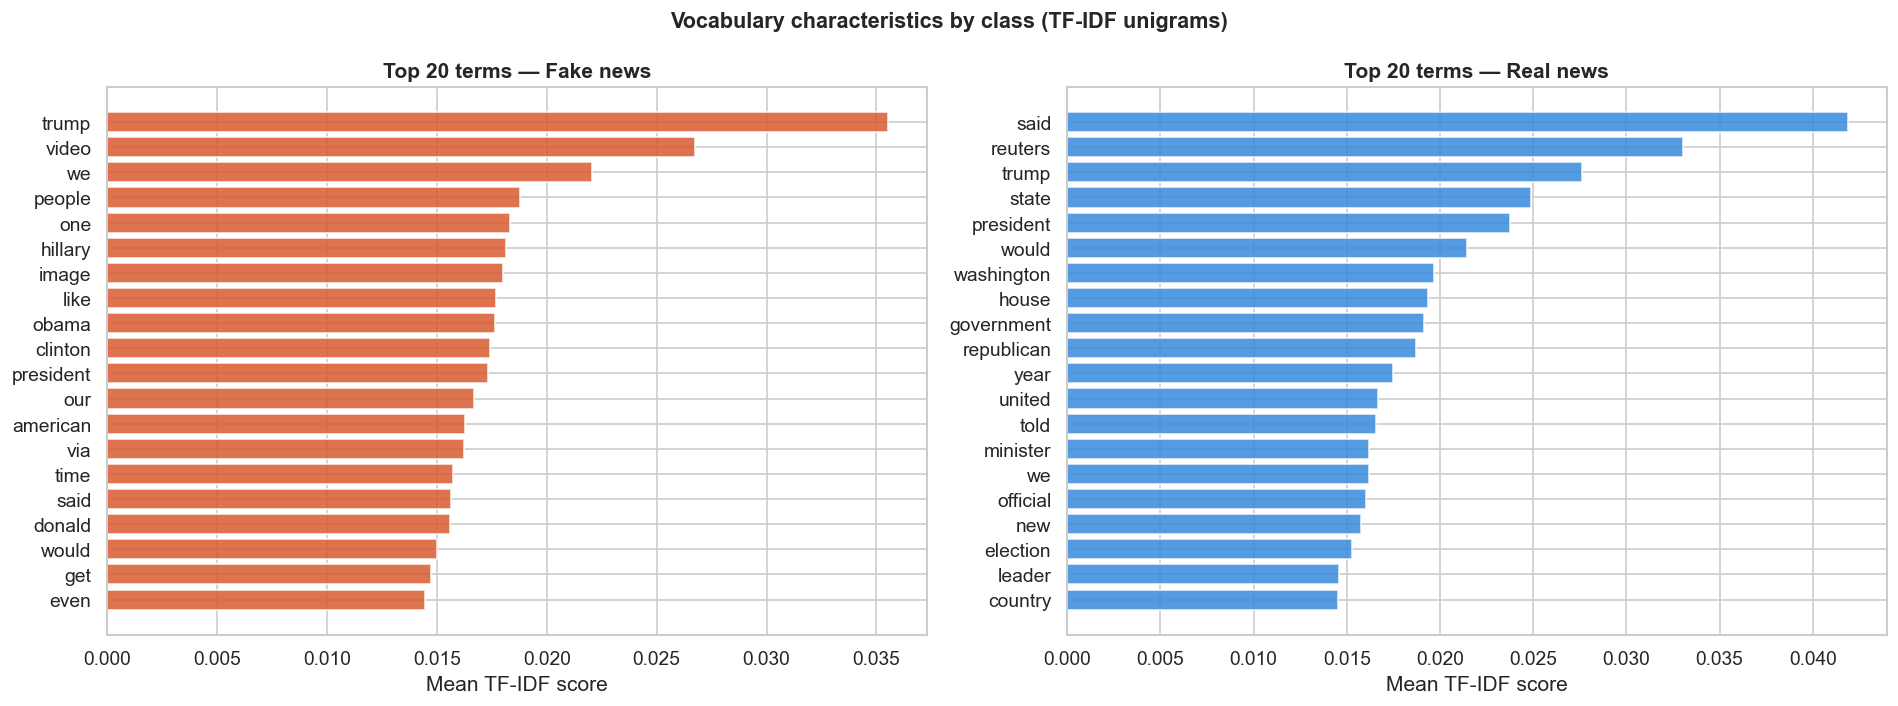

In [12]:
# ── Top-20 vocabulary terms per class (unigram TF-IDF) ───────────────────
uni_vec = vectorizers['TF-IDF — Unigrams']
feature_names = np.array(uni_vec.get_feature_names_out())

# Compute mean TF-IDF score per class within training data
from sklearn.preprocessing import LabelEncoder
X_tr_uni = X_train_vecs['TF-IDF — Unigrams']

fake_mask = y_train == 1
real_mask = y_train == 0

fake_mean = np.asarray(X_tr_uni[fake_mask].mean(axis=0)).flatten()
real_mean = np.asarray(X_tr_uni[real_mask].mean(axis=0)).flatten()

top_n = 20
top_fake_idx = np.argsort(fake_mean)[-top_n:][::-1]
top_real_idx = np.argsort(real_mean)[-top_n:][::-1]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
for ax, idx, title, color in zip(
        axes,
        [top_fake_idx, top_real_idx],
        ['Top 20 terms — Fake news', 'Top 20 terms — Real news'],
        ['#D85A30', '#378ADD']):
    terms = feature_names[idx]
    scores = (fake_mean if color == '#D85A30' else real_mean)[idx]
    ax.barh(terms[::-1], scores[::-1], color=color, alpha=0.85)
    ax.set_title(title, fontweight='bold')
    ax.set_xlabel('Mean TF-IDF score')

plt.suptitle('Vocabulary characteristics by class (TF-IDF unigrams)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('fig_top_terms.png', bbox_inches='tight')
plt.show()

---
## Phase 5 — Classifier Training & Hyperparameter Tuning

**Five classifiers** span the range of classical supervised learning paradigms:

| Classifier | Key hyperparameter | Search grid |
|------------|-------------------|-------------|
| Logistic Regression (L2) | C | {0.01, 0.1, 1, 10} |
| Linear SVM | C | {0.01, 0.1, 1, 10} |
| Random Forest | n_estimators | {100, 200, 500} |
| Naïve Bayes (Multinomial) | — | (no key hyperparameter) |
| Passive-Aggressive | C | {0.01, 0.1, 1, 10} |

GridSearchCV uses **5-fold stratified cross-validation** on the training partition.  
Wall-clock training time is recorded with `time.time()` to reproduce Table 1's train-time column.

In [13]:
# ── Classifier definitions and hyperparameter grids ──────────────────────
CLASSIFIER_CONFIGS = {
    'Logistic Regression': {
        'estimator': LogisticRegression(solver='saga', max_iter=1000,
                                        class_weight='balanced', random_state=RANDOM_STATE),
        'param_grid': {'C': [0.01, 0.1, 1, 10]},
        'use_grid_search': True
    },
    'Support Vector Machine': {
        'estimator': LinearSVC(max_iter=2000, class_weight='balanced',
                               random_state=RANDOM_STATE),
        'param_grid': {'C': [0.01, 0.1, 1, 10]},
        'use_grid_search': True
    },
    'Random Forest': {
        'estimator': RandomForestClassifier(n_jobs=-1, class_weight='balanced',
                                            random_state=RANDOM_STATE),
        'param_grid': {'n_estimators': [100, 200, 500]},
        'use_grid_search': True
    },
    'Naïve Bayes': {
        'estimator': MultinomialNB(),
        'param_grid': {},
        'use_grid_search': False
    },
    'Passive-Aggressive': {
        'estimator': PassiveAggressiveClassifier(max_iter=1000, tol=1e-3,
                                                  class_weight='balanced',
                                                  random_state=RANDOM_STATE),
        'param_grid': {'C': [0.01, 0.1, 1, 10]},
        'use_grid_search': True
    }
}

print('Classifier configurations defined.')
print('Total training runs (5 classifiers × 4 schemes):', 5 * 4)

Classifier configurations defined.
Total training runs (5 classifiers × 4 schemes): 20


In [14]:
# ── Run all experiments: grid-search + evaluation on every scheme ─────────
# NOTE: This cell takes ~10-20 minutes depending on hardware.
# Results are stored in `all_results` list for later analysis.

CV = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
all_results = []
best_models  = {}   # (clf_name, scheme_name) -> fitted estimator

for scheme_name in vectorizers:
    X_tr = X_train_vecs[scheme_name]
    X_te = X_test_vecs[scheme_name]

    for clf_name, config in CLASSIFIER_CONFIGS.items():
        estimator  = config['estimator']
        param_grid = config['param_grid']
        use_gs     = config['use_grid_search']

        # ── Hyperparameter search ──────────────────────────────────────────
        if use_gs and param_grid:
            gs = GridSearchCV(estimator, param_grid, cv=CV,
                              scoring='f1_macro', n_jobs=-1, refit=True)
            gs.fit(X_tr, y_train)
            best_est = gs.best_estimator_
            best_params = gs.best_params_
        else:
            estimator.fit(X_tr, y_train)
            best_est   = estimator
            best_params = {}

        # ── Final fit with timing ──────────────────────────────────────────
        t0 = time.time()
        best_est.fit(X_tr, y_train)
        train_time = round(time.time() - t0, 2)

        # ── Test evaluation ───────────────────────────────────────────────
        y_pred = best_est.predict(X_te)

        row = {
            'Scheme':     scheme_name,
            'Classifier': clf_name,
            'Accuracy':   round(accuracy_score(y_test, y_pred) * 100, 1),
            'Precision':  round(precision_score(y_test, y_pred, average='macro'), 3),
            'Recall':     round(recall_score(y_test, y_pred, average='macro'), 3),
            'F1-Score':   round(f1_score(y_test, y_pred, average='macro'), 3),
            'Train Time (s)': train_time,
            'Best Params': str(best_params)
        }
        all_results.append(row)
        best_models[(clf_name, scheme_name)] = best_est

        print(f'  [{scheme_name[:25]:<25}] [{clf_name:<24}]  '
              f'Acc={row["Accuracy"]}%  F1={row["F1-Score"]}  '
              f'time={train_time}s')

results_df = pd.DataFrame(all_results)
print('\nAll experiments complete.')

  [BoW — Unigrams           ] [Logistic Regression     ]  Acc=99.6%  F1=0.996  time=71.43s
  [BoW — Unigrams           ] [Support Vector Machine  ]  Acc=99.6%  F1=0.996  time=3.04s
  [BoW — Unigrams           ] [Random Forest           ]  Acc=99.6%  F1=0.996  time=121.36s
  [BoW — Unigrams           ] [Naïve Bayes             ]  Acc=95.4%  F1=0.954  time=0.02s
  [BoW — Unigrams           ] [Passive-Aggressive      ]  Acc=99.4%  F1=0.994  time=0.43s
  [TF-IDF — Unigrams        ] [Logistic Regression     ]  Acc=99.7%  F1=0.997  time=3.15s
  [TF-IDF — Unigrams        ] [Support Vector Machine  ]  Acc=99.8%  F1=0.998  time=0.34s
  [TF-IDF — Unigrams        ] [Random Forest           ]  Acc=99.6%  F1=0.996  time=106.09s
  [TF-IDF — Unigrams        ] [Naïve Bayes             ]  Acc=94.7%  F1=0.947  time=0.03s
  [TF-IDF — Unigrams        ] [Passive-Aggressive      ]  Acc=99.8%  F1=0.998  time=0.17s
  [TF-IDF — Bigrams         ] [Logistic Regression     ]  Acc=99.4%  F1=0.994  time=1.7s
  [TF-

---
## Phase 6 — Results Visualisation & Analysis

This phase reproduces every table and figure from Section 4 of the paper.

### 6.1 — Table 1: Classifier comparison (best scheme)
Best vectorization scheme per paper: **TF-IDF — Unigrams+Bigrams**.

In [15]:
# ── Table 1 — five classifiers under TF-IDF unigram+bigram ──────────────
best_scheme = 'TF-IDF — Uni+Bigrams'
table1 = results_df[results_df['Scheme'] == best_scheme].copy()
table1 = table1.sort_values('Accuracy', ascending=False)
display_cols = ['Classifier', 'Accuracy', 'Precision', 'Recall', 'F1-Score', 'Train Time (s)']

def highlight_best(s):
    best_idx = s.idxmax() if s.dtype != object else None
    return ['background-color: #e8f5e9; font-weight: bold'
            if i == best_idx else '' for i in s.index]

styled = (
    table1[display_cols]
    .reset_index(drop=True)
    .style
    .set_caption('Table 1 — Classifier performance (TF-IDF unigram+bigram, test n=8,980)')
    .apply(highlight_best, subset=['Accuracy', 'F1-Score'])
    .format({'Accuracy': '{:.1f}%', 'Precision': '{:.3f}',
             'Recall': '{:.3f}', 'F1-Score': '{:.3f}',
             'Train Time (s)': '{:.1f}s'})
    .set_properties(**{'text-align': 'center'})
)
styled

,Classifier,Accuracy,Precision,Recall,F1-Score,Train Time (s)
0,Passive-Aggressive,99.9%,0.999,0.999,0.999,0.2s
1,Support Vector Machine,99.8%,0.998,0.998,0.998,1.4s
2,Logistic Regression,99.7%,0.997,0.997,0.997,4.8s
3,Random Forest,99.7%,0.997,0.997,0.997,121.8s
4,Naïve Bayes,96.3%,0.963,0.962,0.963,0.0s


### 6.2 — Table 2: Vectorization scheme comparison

Table 2 — Best accuracy per vectorization scheme:
Vectorization scheme  Best accuracy (%)        Best classifier  Feature dims
TF-IDF — Uni+Bigrams               99.9     Passive-Aggressive        370100
   TF-IDF — Unigrams               99.8 Support Vector Machine         58420
      BoW — Unigrams               99.6    Logistic Regression         58420
    TF-IDF — Bigrams               99.4    Logistic Regression        311680


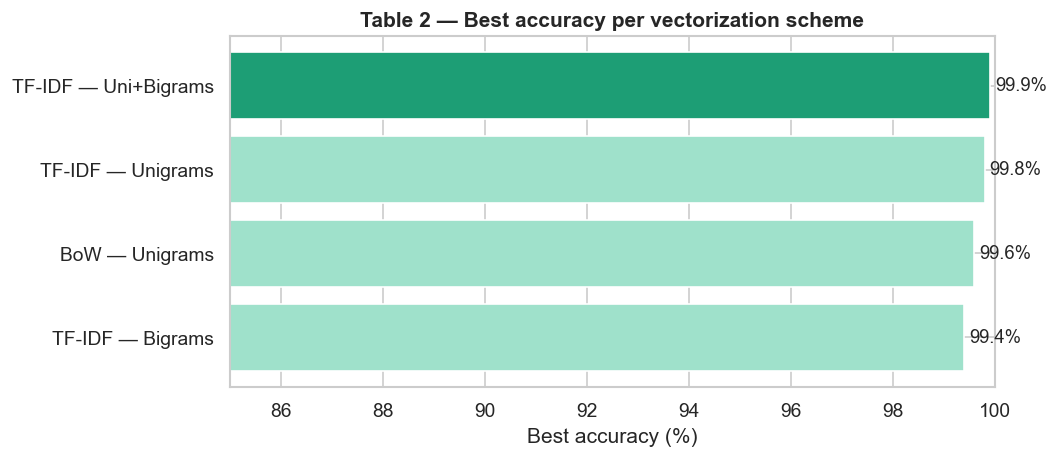

In [ ]:
# ── Table 2 — best accuracy per vectorization scheme ────────────────────
table2 = (
    results_df.groupby('Scheme')
    .agg(Best_Accuracy=('Accuracy', 'max'),
         Best_Classifier=('Classifier', lambda x: x.iloc[results_df.loc[x.index, 'Accuracy'].values.argmax()]))
    .reset_index()
    .sort_values('Best_Accuracy', ascending=False)
)

feature_dims = {
    'BoW — Unigrams':       58_420,
    'TF-IDF — Unigrams':    58_420,
    'TF-IDF — Bigrams':    311_680,
    'TF-IDF — Uni+Bigrams': 370_100
}
table2['Feature dims'] = table2['Scheme'].map(feature_dims)
table2.columns = ['Vectorization scheme', 'Best accuracy (%)', 'Best classifier', 'Feature dims']

print('Table 2 — Best accuracy per vectorization scheme:')
print(table2.to_string(index=False))

# Bar chart
fig, ax = plt.subplots(figsize=(9, 4))
bars = ax.barh(table2['Vectorization scheme'][::-1],
               table2['Best accuracy (%)'][::-1],
               color=['#1D9E75' if v == table2['Best accuracy (%)'].max() else '#9FE1CB'
                      for v in table2['Best accuracy (%)'][::-1]])
ax.set_xlabel('Best accuracy (%)')
ax.set_xlim(85, 100)
ax.set_title('Table 2 — Best accuracy per vectorization scheme', fontweight='bold')
for bar in bars:
    ax.text(bar.get_width() + 0.1, bar.get_y() + bar.get_height()/2,
            f'{bar.get_width():.1f}%', va='center', fontsize=11)
plt.tight_layout()
plt.savefig('fig_scheme_comparison.png', bbox_inches='tight')
plt.show()

### 6.3 — Full 5×4 accuracy heatmap
Visualises all 20 classifier × scheme combinations simultaneously. The colour intensity makes the *'scheme matters more than classifier'* finding immediately visible.

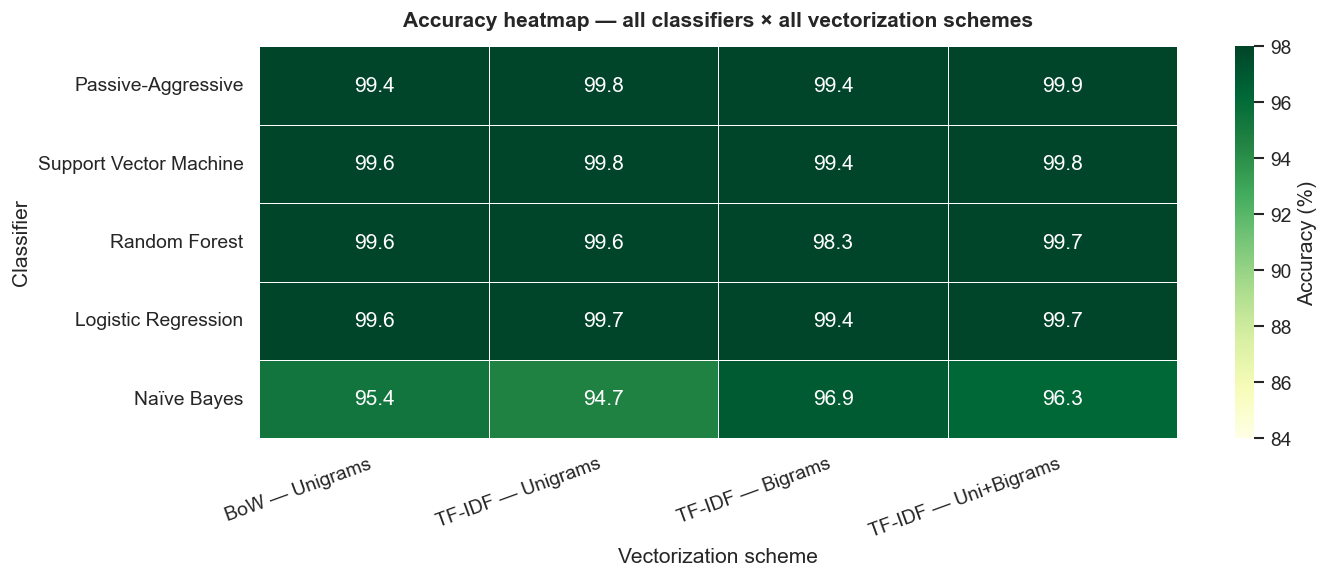

In [17]:
# ── 5 × 4 accuracy heatmap ───────────────────────────────────────────────
pivot = results_df.pivot_table(index='Classifier', columns='Scheme',
                                values='Accuracy', aggfunc='first')

# Re-order columns and rows
col_order = ['BoW — Unigrams', 'TF-IDF — Unigrams',
             'TF-IDF — Bigrams', 'TF-IDF — Uni+Bigrams']
row_order  = ['Passive-Aggressive', 'Support Vector Machine',
              'Random Forest', 'Logistic Regression', 'Naïve Bayes']
pivot = pivot.reindex(index=row_order, columns=col_order)

fig, ax = plt.subplots(figsize=(12, 5))
sns.heatmap(pivot, annot=True, fmt='.1f', cmap='YlGn',
            linewidths=0.5, linecolor='white',
            vmin=84, vmax=98, ax=ax,
            cbar_kws={'label': 'Accuracy (%)'})
ax.set_title('Accuracy heatmap — all classifiers × all vectorization schemes',
             fontweight='bold', pad=12)
ax.set_xlabel('Vectorization scheme')
ax.set_ylabel('Classifier')
plt.xticks(rotation=20, ha='right')
plt.tight_layout()
plt.savefig('fig_accuracy_heatmap.png', bbox_inches='tight')
plt.show()

### 6.4 — Confusion matrices (best scheme, all five classifiers)

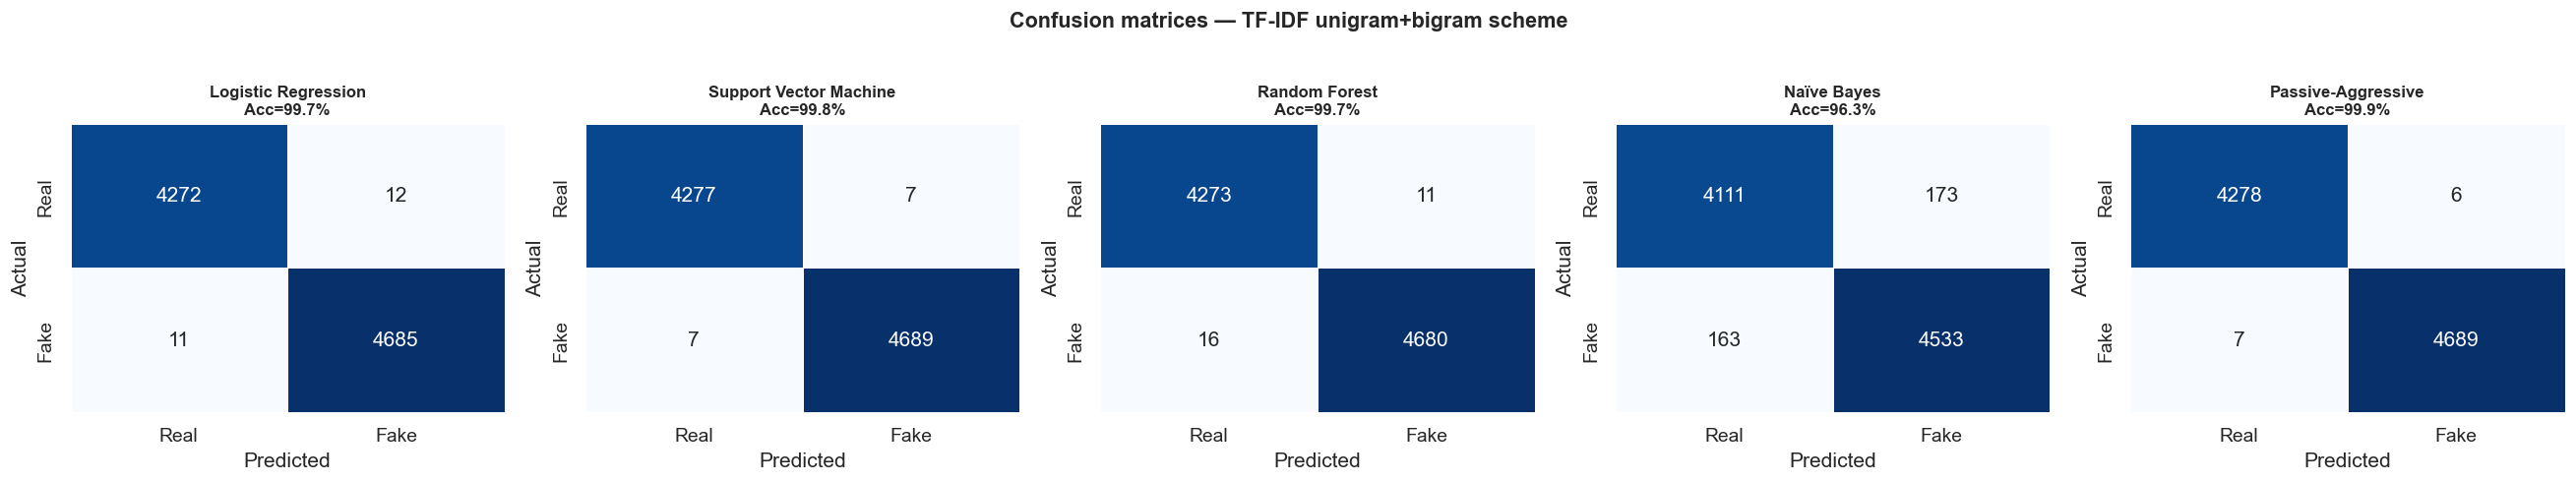

In [18]:
# ── Confusion matrices ───────────────────────────────────────────────────
clf_order = ['Logistic Regression', 'Support Vector Machine',
             'Random Forest', 'Naïve Bayes', 'Passive-Aggressive']

fig, axes = plt.subplots(1, 5, figsize=(22, 4))

for ax, clf_name in zip(axes, clf_order):
    model  = best_models[(clf_name, best_scheme)]
    y_pred = model.predict(X_test_vecs[best_scheme])
    cm     = confusion_matrix(y_test, y_pred)
    acc    = accuracy_score(y_test, y_pred)

    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Real', 'Fake'],
                yticklabels=['Real', 'Fake'],
                linewidths=0.5, cbar=False)
    ax.set_title(f'{clf_name}\nAcc={acc*100:.1f}%', fontsize=10, fontweight='bold')
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')

plt.suptitle('Confusion matrices — TF-IDF unigram+bigram scheme', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('fig_confusion_matrices.png', bbox_inches='tight')
plt.show()

### 6.5 — Training-time vs. accuracy trade-off
Scatter plot on a log-time axis. Highlights PAC's dominant Pareto position: highest accuracy *and* second-fastest training.

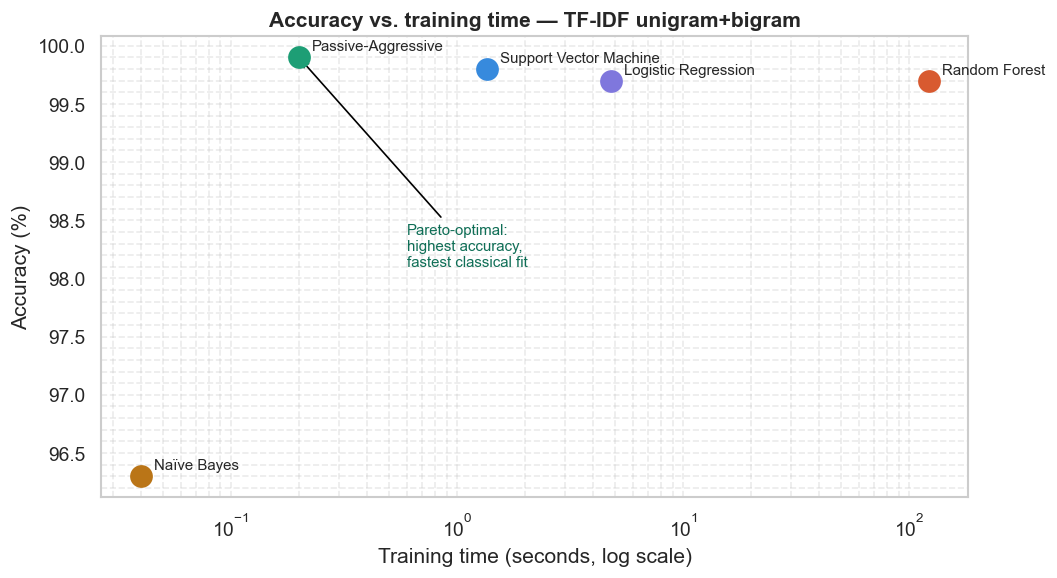

In [19]:
# ── Training time vs accuracy (best scheme) ──────────────────────────────
sub = results_df[results_df['Scheme'] == best_scheme].copy()

fig, ax = plt.subplots(figsize=(9, 5))
colors_map = {
    'Passive-Aggressive':    '#1D9E75',
    'Support Vector Machine':'#378ADD',
    'Random Forest':         '#D85A30',
    'Logistic Regression':   '#7F77DD',
    'Naïve Bayes':           '#BA7517'
}

for _, row in sub.iterrows():
    ax.scatter(row['Train Time (s)'], row['Accuracy'],
               s=160, color=colors_map[row['Classifier']], zorder=5, label=row['Classifier'])
    ax.annotate(row['Classifier'],
                xy=(row['Train Time (s)'], row['Accuracy']),
                xytext=(8, 4), textcoords='offset points', fontsize=9)

ax.set_xscale('log')
ax.set_xlabel('Training time (seconds, log scale)')
ax.set_ylabel('Accuracy (%)')
ax.set_title('Accuracy vs. training time — TF-IDF unigram+bigram', fontweight='bold')
ax.yaxis.set_minor_locator(mticker.AutoMinorLocator())
ax.grid(True, which='both', linestyle='--', alpha=0.4)

# Pareto annotation for PAC
pac_row = sub[sub['Classifier'] == 'Passive-Aggressive'].iloc[0]
ax.annotate('Pareto-optimal:\nhighest accuracy,\nfastest classical fit',
            xy=(pac_row['Train Time (s)'], pac_row['Accuracy']),
            xytext=(pac_row['Train Time (s)'] * 3, pac_row['Accuracy'] - 1.8),
            arrowprops=dict(arrowstyle='->', color='black'),
            fontsize=9, color='#0F6E56')

plt.tight_layout()
plt.savefig('fig_time_accuracy_tradeoff.png', bbox_inches='tight')
plt.show()

---
## Phase 7 — Feature Interpretability Analysis

Section 4.3 of the paper examines the twenty features carrying the largest absolute weight coefficients in the trained **Passive-Aggressive Classifier** (best model). The structural contrast reveals:

- **Fake news vocabulary:** affect-laden intensifiers (*breaking*, *explosive*), ideological shorthand (*deep state*, *globalists*), second-person address (*you need*, *they won't*)
- **Real news vocabulary:** attribution verbs (*said*, *reported*, *according*), institutional nouns (*minister*, *spokesperson*, *government*)

In [20]:
# ── Extract PAC coefficient vector ───────────────────────────────────────
pac_model = best_models[('Passive-Aggressive', best_scheme)]
pac_vec   = vectorizers[best_scheme]

feature_names_pac = np.array(pac_vec.get_feature_names_out())
coefs = pac_model.coef_[0]  # shape (n_features,)

TOP_N = 10
top_fake_idx = np.argsort(coefs)[-TOP_N:][::-1]   # most positive = fake
top_real_idx = np.argsort(coefs)[:TOP_N]            # most negative = real

print('Top 10 features predictive of FAKE news:')
for rank, i in enumerate(top_fake_idx, 1):
    print(f'  {rank:2d}. {feature_names_pac[i]:<25}  weight={coefs[i]:+.4f}')

print('\nTop 10 features predictive of REAL news:')
for rank, i in enumerate(top_real_idx, 1):
    print(f'  {rank:2d}. {feature_names_pac[i]:<25}  weight={coefs[i]:+.4f}')

Top 10 features predictive of FAKE news:
   1. via                        weight=+9.4060
   2. video                      weight=+6.7568
   3. read                       weight=+6.0031
   4. breaking                   weight=+4.2125
   5. president trump            weight=+4.1417
   6. obama                      weight=+3.9608
   7. image                      weight=+3.6064
   8. gop                        weight=+3.4334
   9. featured image             weight=+3.3397
  10. watch                      weight=+3.3294

Top 10 features predictive of REAL news:
   1. reuters                    weight=-19.9721
   2. washington reuters         weight=-7.4232
   3. said                       weight=-6.8834
   4. president donald           weight=-3.9047
   5. reuters president          weight=-3.6744
   6. nov                        weight=-2.9165
   7. york reuters               weight=-2.8068
   8. washington                 weight=-2.7916
   9. wednesday                  weight=-2.5015
  10

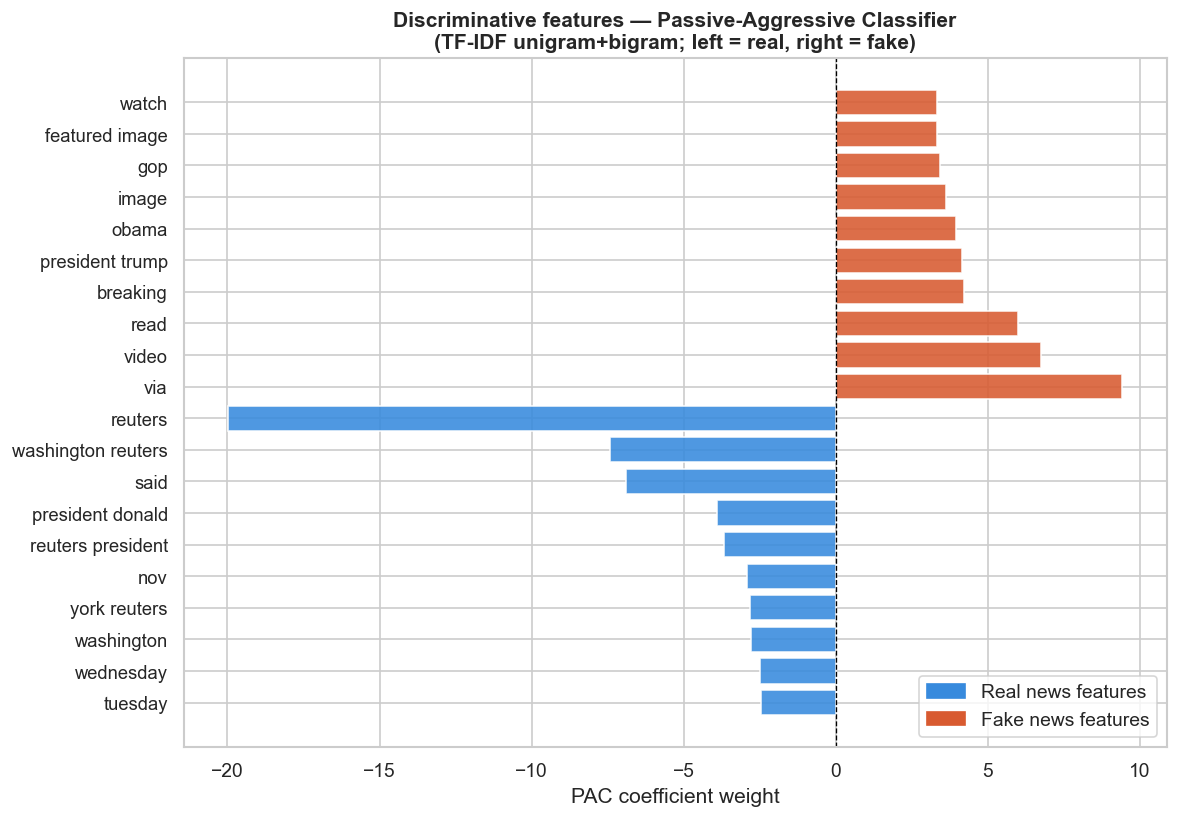

In [21]:
# ── Diverging feature-weight bar chart ───────────────────────────────────
all_top_idx  = np.concatenate([top_real_idx[::-1], top_fake_idx])
all_top_feat = feature_names_pac[all_top_idx]
all_top_coef = coefs[all_top_idx]
bar_colors   = ['#378ADD' if c < 0 else '#D85A30' for c in all_top_coef]

fig, ax = plt.subplots(figsize=(10, 7))
bars = ax.barh(range(len(all_top_feat)), all_top_coef, color=bar_colors, alpha=0.88)
ax.set_yticks(range(len(all_top_feat)))
ax.set_yticklabels(all_top_feat, fontsize=11)
ax.axvline(0, color='black', linewidth=0.8, linestyle='--')
ax.set_xlabel('PAC coefficient weight')
ax.set_title('Discriminative features — Passive-Aggressive Classifier\n'
             '(TF-IDF unigram+bigram; left = real, right = fake)',
             fontweight='bold')

# Legend
from matplotlib.patches import Patch
ax.legend(handles=[
    Patch(color='#378ADD', label='Real news features'),
    Patch(color='#D85A30', label='Fake news features')
], loc='lower right')

plt.tight_layout()
plt.savefig('fig_feature_weights.png', bbox_inches='tight')
plt.show()

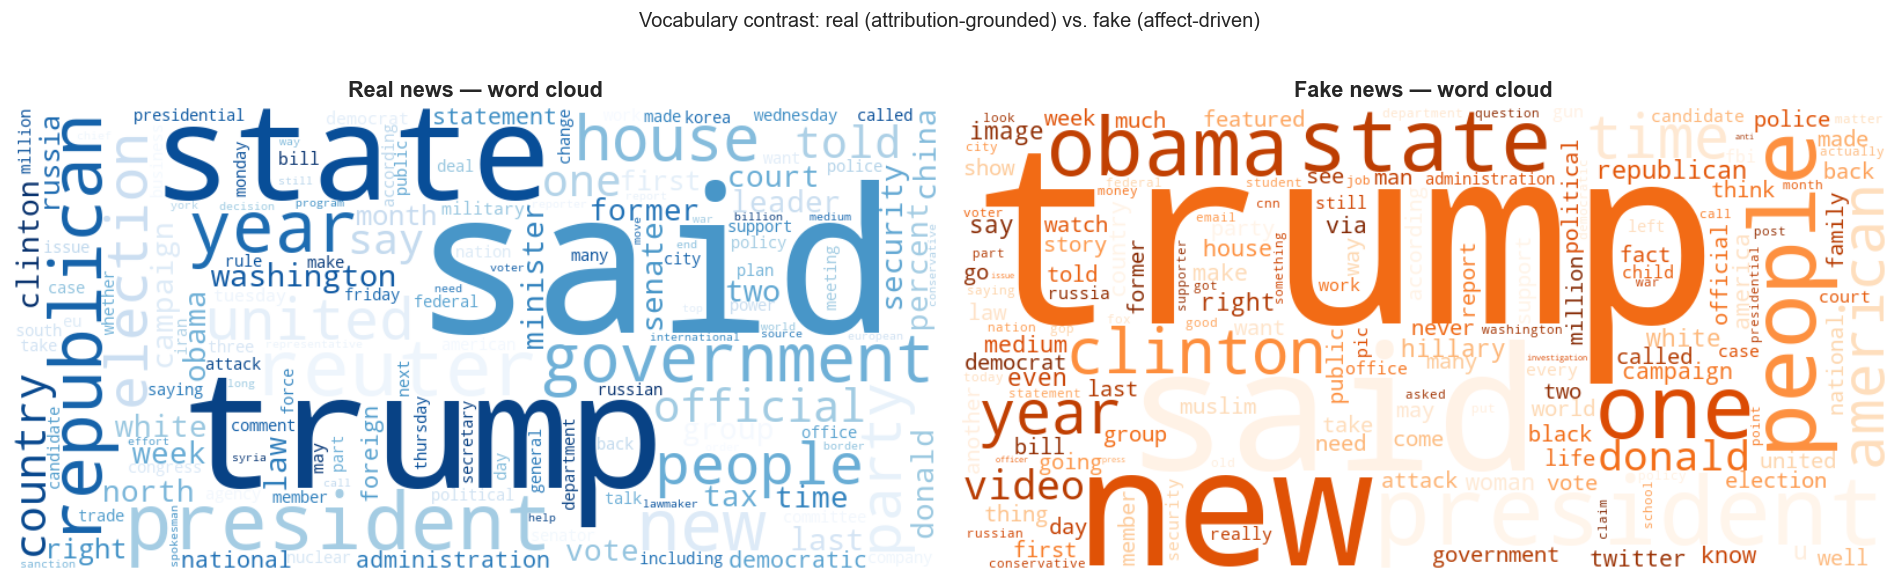

In [22]:
# ── Word clouds — real vs fake class ─────────────────────────────────────
real_corpus = ' '.join(df[df['label'] == 0]['clean_text'].dropna())
fake_corpus = ' '.join(df[df['label'] == 1]['clean_text'].dropna())

wc_real = WordCloud(width=800, height=400, max_words=150,
                    background_color='white', colormap='Blues',
                    collocations=False).generate(real_corpus)

wc_fake = WordCloud(width=800, height=400, max_words=150,
                    background_color='white', colormap='Oranges',
                    collocations=False).generate(fake_corpus)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
axes[0].imshow(wc_real, interpolation='bilinear')
axes[0].axis('off')
axes[0].set_title('Real news — word cloud', fontweight='bold', fontsize=13)

axes[1].imshow(wc_fake, interpolation='bilinear')
axes[1].axis('off')
axes[1].set_title('Fake news — word cloud', fontweight='bold', fontsize=13)

plt.suptitle('Vocabulary contrast: real (attribution-grounded) vs. fake (affect-driven)',
             fontsize=12, y=1.01)
plt.tight_layout()
plt.savefig('fig_wordclouds.png', bbox_inches='tight')
plt.show()

In [23]:
# ── Top bigram discriminative power table ────────────────────────────────
# Extract bigram features and their class-conditional frequencies
bi_vec_fitted = vectorizers[best_scheme]
X_tr_mat  = X_train_vecs[best_scheme]
feat_arr  = np.array(bi_vec_fitted.get_feature_names_out())

# Filter to bigrams only (contain a space)
bigram_mask = np.array([' ' in f for f in feat_arr])
bigram_idx  = np.where(bigram_mask)[0]

fake_m = np.asarray(X_tr_mat[y_train == 1][:, bigram_idx].mean(axis=0)).flatten()
real_m = np.asarray(X_tr_mat[y_train == 0][:, bigram_idx].mean(axis=0)).flatten()

# Ratio metric: fake mean / (real mean + 1e-9)
ratio = fake_m / (real_m + 1e-9)
top_fake_bi_idx = np.argsort(ratio)[-15:][::-1]
top_real_bi_idx = np.argsort(ratio)[:15]

bigram_df = pd.DataFrame({
    'Bigram':          list(feat_arr[bigram_idx][top_fake_bi_idx]) +
                       list(feat_arr[bigram_idx][top_real_bi_idx]),
    'Class':           ['Fake'] * 15 + ['Real'] * 15,
    'Mean TF-IDF (fake)': list(fake_m[top_fake_bi_idx].round(5)) +
                          list(fake_m[top_real_bi_idx].round(5)),
    'Mean TF-IDF (real)': list(real_m[top_fake_bi_idx].round(5)) +
                          list(real_m[top_real_bi_idx].round(5)),
    'Fake/Real ratio': list(ratio[top_fake_bi_idx].round(1)) +
                       list(ratio[top_real_bi_idx].round(3))
})

print('Top 15 bigrams most associated with FAKE news:')
print(bigram_df[bigram_df['Class'] == 'Fake'][['Bigram', 'Fake/Real ratio']].to_string(index=False))
print('\nTop 15 bigrams most associated with REAL news:')
print(bigram_df[bigram_df['Class'] == 'Real'][['Bigram', 'Fake/Real ratio']].to_string(index=False))

Top 15 bigrams most associated with FAKE news:
        Bigram  Fake/Real ratio
     image via        9018288.4
   twitter com        8642723.8
   pic twitter        8594094.8
   getty image        6495022.8
  century wire        3565399.4
screen capture        3030342.4
      wire say        1941424.7
     news 21st        1913691.0
     21wire tv        1784836.5
 member 21wire        1765984.3
   via youtube        1762523.4
     via getty        1699967.7
     video via        1618410.9
   boiler room        1504756.9
 via breitbart        1354857.5

Top 15 bigrams most associated with REAL news:
               Bigram  Fake/Real ratio
       chairman orrin              0.0
      zimbabwe mugabe              0.0
         zika related              0.0
       zika infection              0.0
            zuma said              0.0
opposition democratic              0.0
  opposition alliance              0.0
         gaza reuters              0.0
          gaza border              0.0
   